# Lab Assignment - 6

## Part A - Image Feature Extraction and Classification

In [4]:
import numpy as np
import pandas as pd
import os
import cv2


#### Data Inspection

In [5]:
import os

DATA_DIR = "448"

CRACK_DIR = os.path.join(DATA_DIR, "Cracks")
NON_CRACK_DIR = os.path.join(DATA_DIR, "NonCracks")

In [6]:
crack_files = [
    f for f in os.listdir(CRACK_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

non_crack_files = [
    f for f in os.listdir(NON_CRACK_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Crack images    :", len(crack_files))
print("Non-crack images:", len(non_crack_files))
print("Total images    :", len(crack_files) + len(non_crack_files))

Crack images    : 200
Non-crack images: 200
Total images    : 400


In [7]:
print("\nSample crack files:")
print(crack_files[:5])

print("\nSample non-crack files:")
print(non_crack_files[:5])


Sample crack files:
['IMG_20180513_164959951_HDR resized_448.jpg', 'IMG_20180513_165129852_HDR resized_448.jpg', 'IMG_20180513_165150613_HDR resized_448.jpg', 'IMG_20180513_165345878_HDR resized_448.jpg', 'IMG_20180513_165349788_HDR resized_448.jpg']

Sample non-crack files:
['IMG_20180705_130729936 resized_448.jpg', 'IMG_20180705_130731751 resized_448.jpg', 'IMG_20180705_130732496 resized_448.jpg', 'IMG_20180705_130732993 resized_448.jpg', 'IMG_20180705_130733329 resized_448.jpg']


Inspect one image

In [8]:
# Select one crack image
sample_path = os.path.join(CRACK_DIR, crack_files[0])

# Read image using OpenCV
image = cv2.imread(sample_path)

print("Image shape :", image.shape)
print("Data type   :", image.dtype)
print("Min pixel   :", image.min())
print("Max pixel   :", image.max())

Image shape : (448, 448, 3)
Data type   : uint8
Min pixel   : 0
Max pixel   : 255


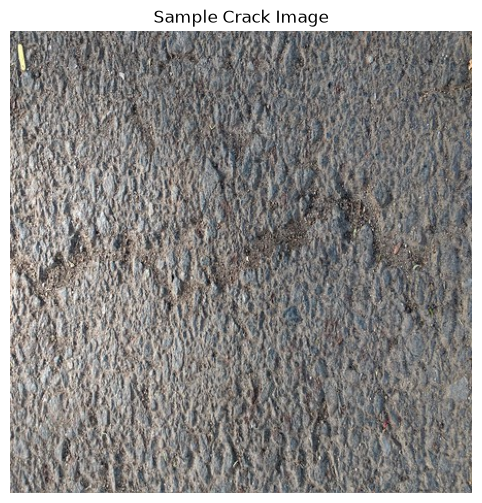

In [9]:
import matplotlib.pyplot as plt
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Sample Crack Image")
plt.axis("off")
plt.show()

Inspect several dimensions

In [10]:
dimensions = []

for filename in crack_files + non_crack_files:
    folder = CRACK_DIR if filename in crack_files else NON_CRACK_DIR
    path = os.path.join(folder, filename)

    image = cv2.imread(path)

    if image is not None:
        dimensions.append(image.shape)

print("Number of successfully loaded images:", len(dimensions))
print("Unique dimensions:", set(dimensions))

Number of successfully loaded images: 400
Unique dimensions: {(448, 448, 3)}


#### Image Preprocessing

In [11]:
# Resize and Grayscale a Sample Image
# Target image size
IMG_SIZE = (128, 128)

# Resize the sample image
resized = cv2.resize(image, IMG_SIZE)

# Convert resized image to grayscale
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

print("Original shape :", image.shape)
print("Resized shape  :", resized.shape)
print("Grayscale shape:", gray.shape)

Original shape : (448, 448, 3)
Resized shape  : (128, 128, 3)
Grayscale shape: (128, 128)


A sample crack image is resized from 448 × 448 to 128 × 128 pixels and then converted into a grayscale representation. 
Because the three channels:B G R are converted into one intensity value per pixel.

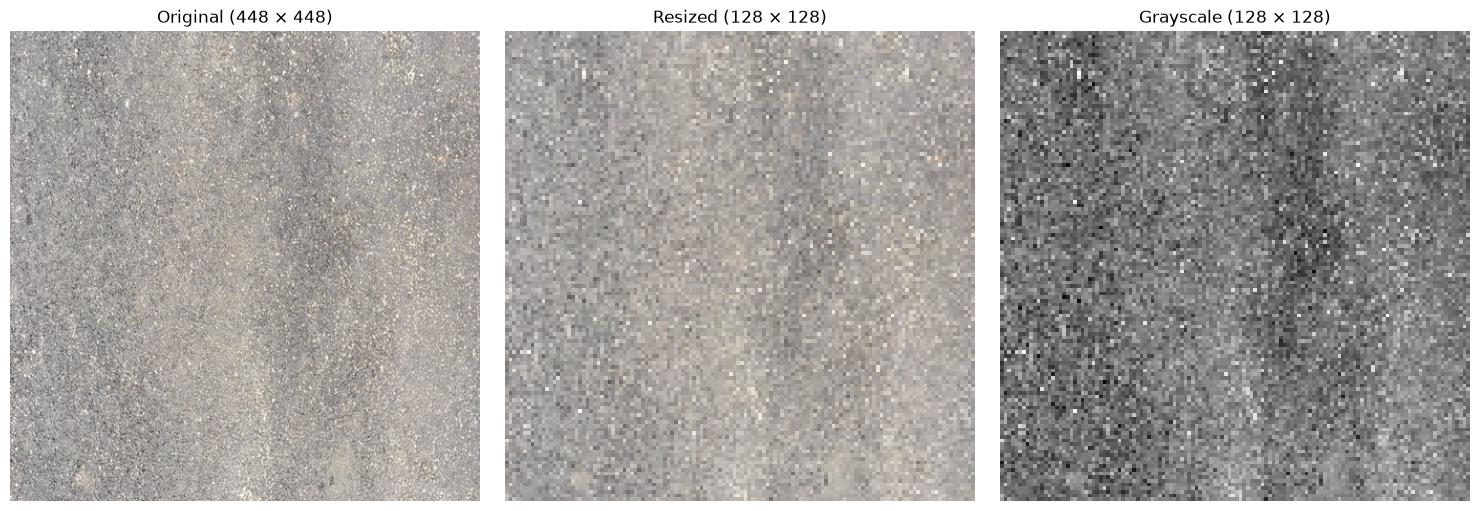

In [12]:
# Convert images for correct Matplotlib display
original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_rgb)
axes[0].set_title("Original (448 × 448)")
axes[0].axis("off")

axes[1].imshow(resized_rgb)
axes[1].set_title("Resized (128 × 128)")
axes[1].axis("off")

axes[2].imshow(gray, cmap="gray")
axes[2].set_title("Grayscale (128 × 128)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Process all images

In [13]:
def preprocess_image(image_path, img_size=(128, 128)):
    """
    Load and preprocess an image.

    Steps:
    1. Read image using OpenCV
    2. Resize to a common size
    3. Convert to grayscale
    """
    
    image = cv2.imread(image_path)
    
    if image is None:
        return None
    
    resized = cv2.resize(image, img_size)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    
    return gray

In [14]:
test_image = preprocess_image(sample_path)

print("Preprocessed shape:", test_image.shape)
print("Data type:", test_image.dtype)

Preprocessed shape: (128, 128)
Data type: uint8


Image Preprocessing Function

A reusable function is defined to apply the same preprocessing steps to every image in the dataset. The function reads an image using OpenCV, resizes it to 128 × 128 pixels, and converts it to grayscale.

### Intensity-Based Feature Extraction



####  Mean Brightness

Mean brightness represents the average grayscale intensity of all pixels in an image.

Higher values indicate a brighter image on average, while lower values indicate a darker image.

In [15]:
mean_brightness = np.mean(gray)

print("Mean brightness:", mean_brightness)

Mean brightness: 165.13671875


#### Contrast

The standard deviation of grayscale intensities is used as a simple measure of image contrast.

A higher standard deviation indicates greater variation in pixel intensities, while a lower value indicates a more uniform intensity distribution.

In [16]:
contrast = np.std(gray)

print("Contrast:", contrast)

Contrast: 17.661648355457537


#### Additional Intensity Statistics

Minimum, maximum, and median grayscale intensity provide additional information about the distribution of pixel values in each image.

In [17]:
min_intensity = np.min(gray)
max_intensity = np.max(gray)
median_intensity = np.median(gray)

print("Minimum intensity :", min_intensity)
print("Maximum intensity :", max_intensity)
print("Median intensity  :", median_intensity)

Minimum intensity : 90
Maximum intensity : 248
Median intensity  : 165.0


#### Dark- and Bright-Pixel Ratios

The dark-pixel ratio represents the proportion of pixels below a selected intensity threshold, while the bright-pixel ratio represents the proportion above a selected threshold.

These features help describe the distribution of dark and bright regions within the image.

In [18]:
DARK_THRESHOLD = 50
BRIGHT_THRESHOLD = 200

dark_pixel_ratio = np.mean(gray < DARK_THRESHOLD)
bright_pixel_ratio = np.mean(gray > BRIGHT_THRESHOLD)

print("Dark-pixel ratio  :", dark_pixel_ratio)
print("Bright-pixel ratio:", bright_pixel_ratio)

Dark-pixel ratio  : 0.0
Bright-pixel ratio: 0.0302734375


The grayscale images are converted into compact numerical representations using statistical intensity features.

The extracted features include:

- Mean brightness
- Median intensity
- Standard deviation (contrast)
- Minimum intensity
- Maximum intensity
- Dark-pixel ratio
- Bright-pixel ratio

These features summarize the overall brightness, intensity variation, and distribution of pixels in each image.

### Canny Edge Feature Extraction

Canny edge detector does not know what a crack looks like; it only knows how to look for sudden changes in brightness.

Cracks often appear as elongated structures with changes in image intensity. Canny edge detection is therefore used to identify edge pixels in the grayscale image.

The resulting edge map is used to calculate:

- Edge count
- Edge density

In [19]:
CANNY_LOW = 100
CANNY_HIGH = 200

edges = cv2.Canny(gray, CANNY_LOW, CANNY_HIGH)

edge_count = np.sum(edges > 0)
edge_density = np.mean(edges > 0)

print("Edge count   :", edge_count)
print("Edge density :", edge_density)

Edge count   : 2314
Edge density : 0.1412353515625


#### Canny Edge Visualization

The grayscale image and its corresponding Canny edge map are visualized to observe the edges detected by the algorithm.

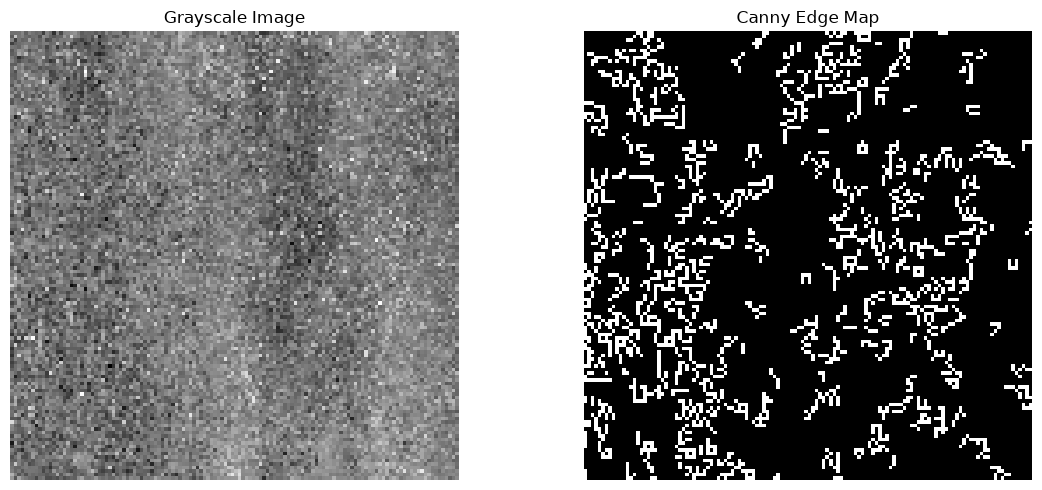

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale Image")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Canny Edge Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Complete Image Feature Extraction

A single feature-extraction function is used to process every image consistently.

For each image, the function:
1. Loads the image using OpenCV.
2. Resizes it to 128 × 128 pixels.
3. Converts it to grayscale.
4. Calculates intensity-based features.
5. Applies Canny edge detection.
6. Calculates edge-based features.

Each image is represented by one numerical feature vector.

In [22]:
def extract_features(image_path, img_size=(128, 128)):
    """
    Load an image, preprocess it, and extract numerical features.
    """

    # Load image
    image = cv2.imread(image_path)

    if image is None:
        return None

    # Preprocessing
    resized = cv2.resize(image, img_size)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Intensity features
    mean_brightness = np.mean(gray)
    median_intensity = np.median(gray)
    contrast = np.std(gray)
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)

    # Pixel ratio features
    dark_pixel_ratio = np.mean(gray < DARK_THRESHOLD)
    bright_pixel_ratio = np.mean(gray > BRIGHT_THRESHOLD)

    # Canny edge detection
    edges = cv2.Canny(gray, CANNY_LOW, CANNY_HIGH)

    # Edge features
    edge_count = np.sum(edges > 0)
    edge_density = np.mean(edges > 0)

    return {
        "mean_brightness": mean_brightness,
        "median_intensity": median_intensity,
        "contrast": contrast,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "edge_count": edge_count,
        "edge_density": edge_density
    }

In [23]:
test_features = extract_features(sample_path)

test_features

{'mean_brightness': np.float64(122.26397705078125),
 'median_intensity': np.float64(121.0),
 'contrast': np.float64(33.070752030262774),
 'min_intensity': np.uint8(27),
 'max_intensity': np.uint8(247),
 'dark_pixel_ratio': np.float64(0.005859375),
 'bright_pixel_ratio': np.float64(0.01446533203125),
 'edge_count': np.int64(5580),
 'edge_density': np.float64(0.340576171875)}

### Build the Image Feature Dataset

In [24]:
feature_rows = []

# Process crack images
for filename in crack_files:
    image_path = os.path.join(CRACK_DIR, filename)

    features = extract_features(image_path)

    if features is not None:
        features["filename"] = filename
        features["label"] = 1
        feature_rows.append(features)


# Process non-crack images
for filename in non_crack_files:
    image_path = os.path.join(NON_CRACK_DIR, filename)

    features = extract_features(image_path)

    if features is not None:
        features["filename"] = filename
        features["label"] = 0
        feature_rows.append(features)


features_df = pd.DataFrame(feature_rows)

print("Feature dataset shape:", features_df.shape)

Feature dataset shape: (400, 11)


9 extracted features
+ filename
+ label
= 11

### Inspect the Feature Dataset

The resulting feature table is inspected to verify the extracted numerical representation and class labels.

In [28]:
features_df["label"].value_counts()

label
1    200
0    200
Name: count, dtype: int64

In [29]:
features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mean_brightness     400 non-null    float64
 1   median_intensity    400 non-null    float64
 2   contrast            400 non-null    float64
 3   min_intensity       400 non-null    uint8  
 4   max_intensity       400 non-null    uint8  
 5   dark_pixel_ratio    400 non-null    float64
 6   bright_pixel_ratio  400 non-null    float64
 7   edge_count          400 non-null    int64  
 8   edge_density        400 non-null    float64
 9   filename            400 non-null    str    
 10  label               400 non-null    int64  
dtypes: float64(6), int64(2), str(1), uint8(2)
memory usage: 29.0 KB


In [30]:
features_df.head()


,mean_brightness,median_intensity,contrast,min_intensity,max_intensity,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density,filename,label
0,122.263977,121.0,33.070752,27,247,0.005859,0.014465,5580,0.340576,IMG_20180513_164959951_HDR resized_448.jpg,1
1,131.565186,133.0,25.482184,13,252,0.003418,0.004456,4579,0.279480,IMG_20180513_165129852_HDR resized_448.jpg,1
2,121.076355,120.0,31.130490,4,237,0.014221,0.010498,4303,0.262634,IMG_20180513_165150613_HDR resized_448.jpg,1
3,130.309143,131.0,27.282676,8,251,0.002197,0.006592,5507,0.336121,IMG_20180513_165345878_HDR resized_448.jpg,1
4,130.993286,132.0,27.639562,20,252,0.003357,0.007751,5218,0.318481,IMG_20180513_165349788_HDR resized_448.jpg,1


#### Saving the Dataset

In [31]:
features_df.to_csv("image_features.csv", index=False)

print("Saved:", "image_features.csv")

Saved: image_features.csv


### Feature Analysis

#### Statistical Summary of Extracted Features

In [32]:
feature_columns = [
    "mean_brightness",
    "median_intensity",
    "contrast",
    "min_intensity",
    "max_intensity",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density"
]

features_df[feature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
mean_brightness,400.0,150.824035,17.758345,110.385376,134.273758,152.684937,165.949829,189.577637
median_intensity,400.0,150.801250,17.825804,110.000000,135.000000,153.000000,165.000000,190.000000
contrast,400.0,27.827543,8.449777,15.257929,20.027965,27.593828,33.679349,56.364362
min_intensity,400.0,48.857500,32.421986,0.000000,23.750000,45.000000,78.250000,114.000000
max_intensity,400.0,249.615000,5.633927,221.000000,248.750000,251.000000,253.000000,255.000000
dark_pixel_ratio,400.0,0.004825,0.012947,0.000000,0.000000,0.000122,0.003540,0.134705
bright_pixel_ratio,400.0,0.061163,0.055335,0.000366,0.015167,0.049133,0.088394,0.280334
edge_count,400.0,4449.130000,1716.830455,635.000000,3055.250000,5311.500000,5793.750000,6334.000000
edge_density,400.0,0.271553,0.104787,0.038757,0.186478,0.324188,0.353622,0.386597


#### Feature Means by Class

In [33]:
class_feature_means = features_df.groupby("label")[feature_columns].mean()

class_feature_means.index = ["Non-Crack", "Crack"]

class_feature_means.T

,Non-Crack,Crack
mean_brightness,157.444093,144.203977
median_intensity,157.177500,144.425000
contrast,24.398785,31.256302
min_intensity,67.760000,29.955000
max_intensity,248.645000,250.585000
dark_pixel_ratio,0.000552,0.009098
bright_pixel_ratio,0.048096,0.074231
edge_count,3618.635000,5279.625000
edge_density,0.220864,0.322243


#### Visualization

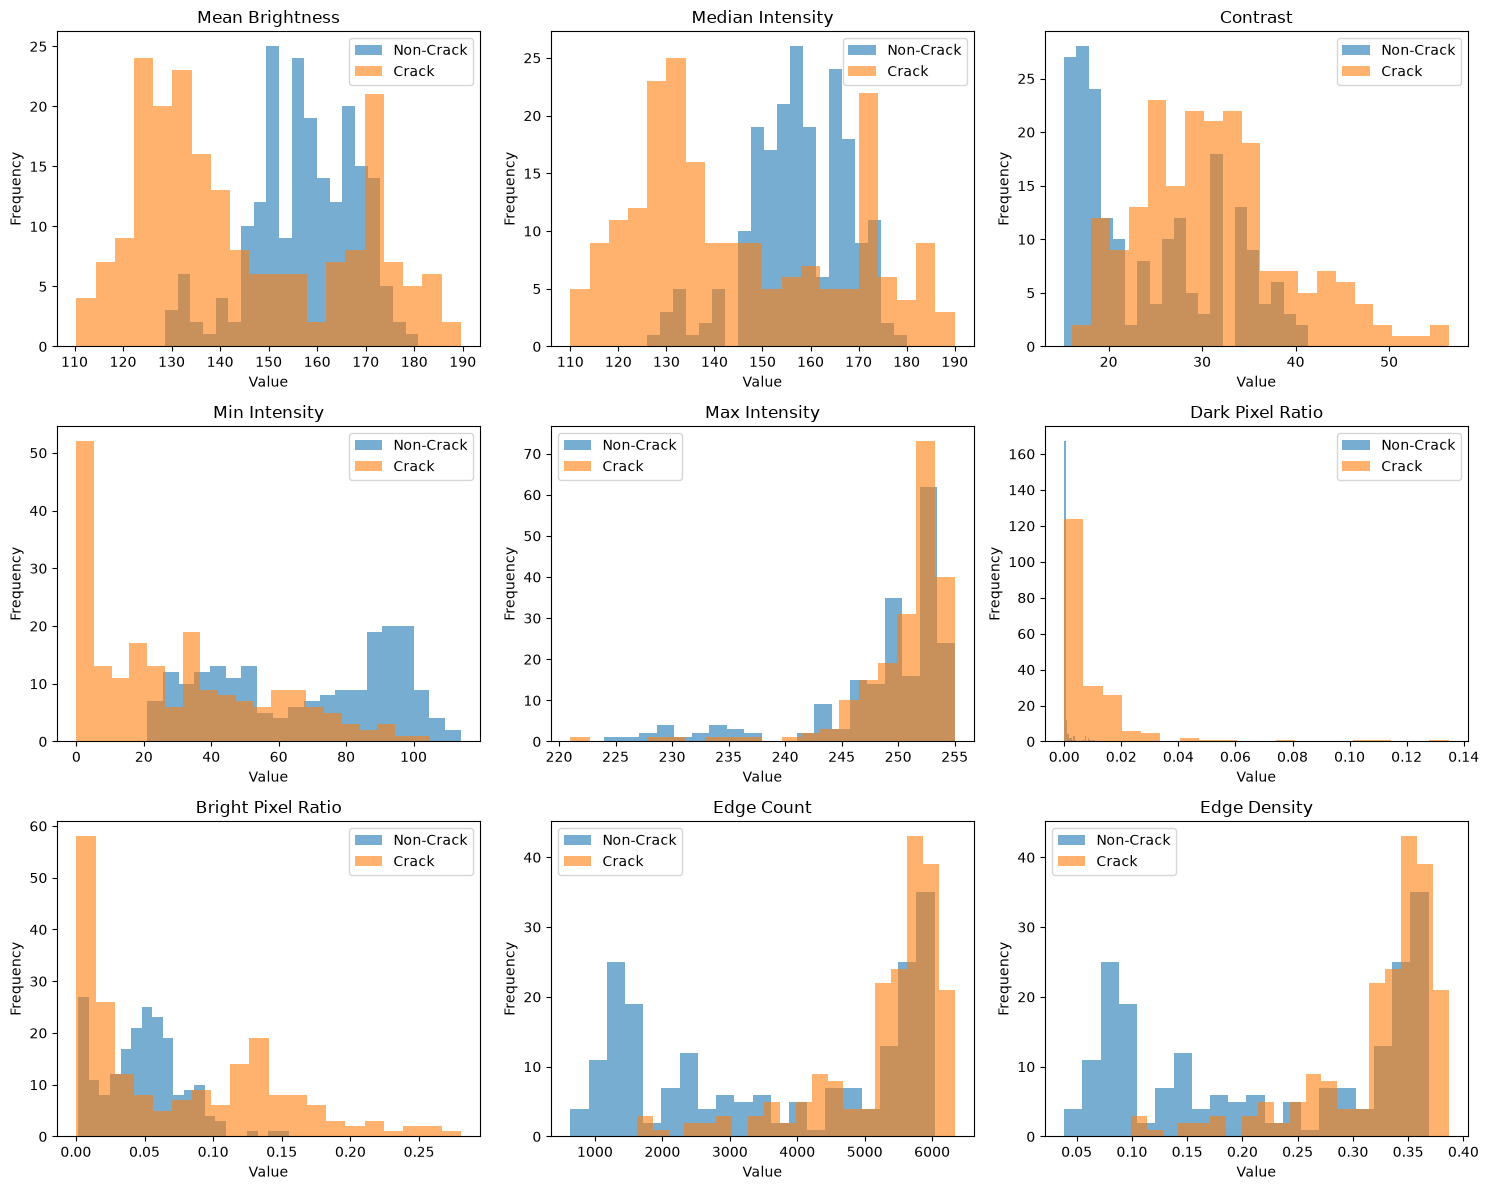

In [34]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, feature in zip(axes.ravel(), feature_columns):
    for label, class_name in [(0, "Non-Crack"), (1, "Crack")]:
        data = features_df.loc[features_df["label"] == label, feature]
        ax.hist(data, bins=20, alpha=0.6, label=class_name)
    
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

#### Feature Correlation

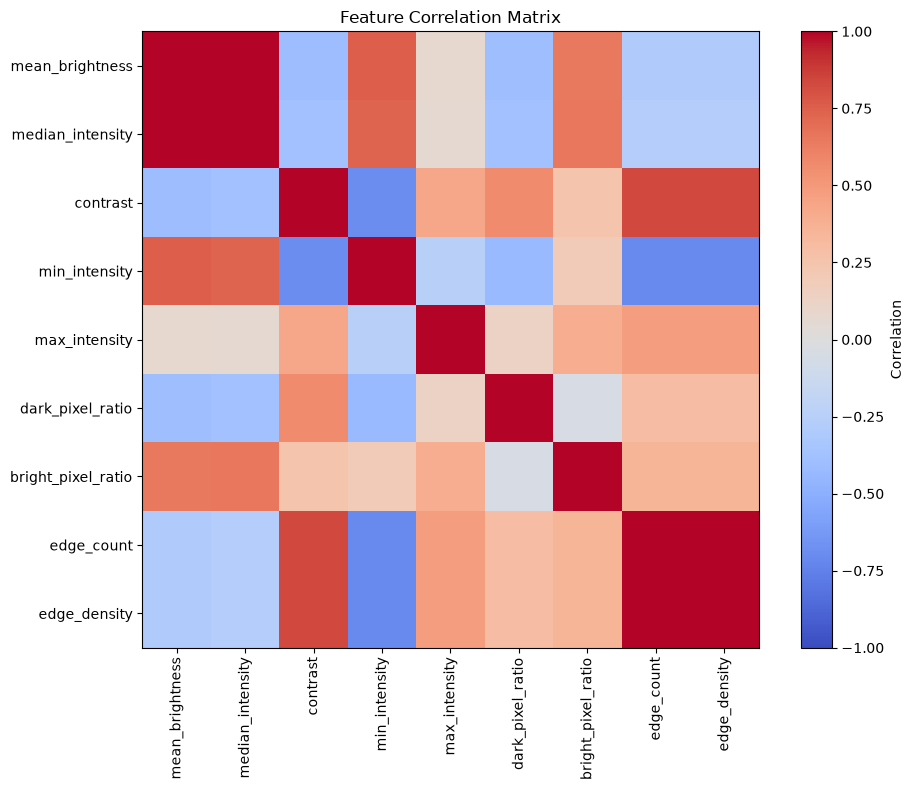

In [35]:
correlation = features_df[feature_columns].corr()

plt.figure(figsize=(10, 8))

plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=90
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split

X = features_df[feature_columns]
y = features_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Training features:", X_train.shape[1])

Training samples: 320
Testing samples : 80
Training features: 9


### Feature Scaling for Logistic Regression

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Scaled training shape: (320, 9)
Scaled testing shape : (80, 9)


### Logistic Regression — Baseline Model

Logistic Regression is used as the baseline classifier.

It provides a simple linear decision boundary for distinguishing crack and non-crack images based on the extracted handcrafted features.

The model is trained using the standardized training features.

In [39]:
from sklearn.linear_model import LogisticRegression
import time
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

start_time = time.perf_counter()

logistic_model.fit(X_train_scaled, y_train)

logistic_train_time = time.perf_counter() - start_time

start_time = time.perf_counter()

y_pred_lr = logistic_model.predict(X_test_scaled)

logistic_prediction_time = time.perf_counter() - start_time

print("Training time   :", logistic_train_time)
print("Prediction time :", logistic_prediction_time)

Training time   : 0.028718799934722483
Prediction time : 0.0009228000417351723


#### Evaluation of logistic Regression

In [40]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression")
print("-" * 30)
print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1-score  : {lr_f1:.4f}")
print(f"Train time: {logistic_train_time:.6f} sec")
print(f"Pred time : {logistic_prediction_time:.6f} sec")

Logistic Regression
------------------------------
Accuracy  : 0.9375
Precision : 0.9268
Recall    : 0.9500
F1-score  : 0.9383
Train time: 0.028719 sec
Pred time : 0.000923 sec


#### Confusion Matrix

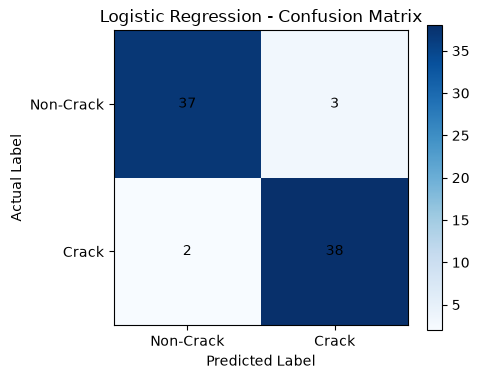

In [41]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))

plt.imshow(cm_lr, cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Non-Crack", "Crack"])
plt.yticks([0, 1], ["Non-Crack", "Crack"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_lr[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

####  Observations

- Logistic Regression achieved an accuracy of **93.75%** on the test set.
- The model achieved a **precision of 92.68%**, indicating that most images predicted as crack were actually crack images.
- The **recall of 95.00%** shows that the model correctly identified most of the actual crack images.
- The **F1-score of 93.83%** indicates a good balance between precision and recall.
- From the confusion matrix, **75 out of 80 test images were classified correctly**: 37 non-crack images and 38 crack images.
- The model incorrectly classified **3 non-crack images as crack** and **2 crack images as non-crack**.
- The training and prediction times were very low, at approximately **0.0027 seconds** and **0.0009 seconds**, respectively.
- Overall, the handcrafted intensity and Canny-based features provide a strong baseline for distinguishing crack and non-crack images using Logistic Regression.

9 handcrafted features
        ->
Logistic Regression
        ->
93.75% test accuracy

### Random Forest Classifier

Random Forest is used as a second traditional machine-learning classifier.

Unlike Logistic Regression, Random Forest can model nonlinear relationships between the handcrafted image features.

Feature scaling is not required for tree-based models, so the original feature values are used.

Logistic Regression
→ linear decision boundary
→ scaled features

Random Forest
→ ensemble of decision trees
→ no feature scaling required

In [42]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Training time
start_time = time.perf_counter()

random_forest.fit(X_train, y_train)

rf_train_time = time.perf_counter() - start_time

# Prediction time
start_time = time.perf_counter()

y_pred_rf = random_forest.predict(X_test)

rf_prediction_time = time.perf_counter() - start_time

print("Training time   :", rf_train_time)
print("Prediction time :", rf_prediction_time)

Training time   : 0.5141662999521941
Prediction time : 0.06351820006966591


In [43]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest")
print("-" * 30)
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-score  : {rf_f1:.4f}")
print(f"Train time: {rf_train_time:.6f} sec")
print(f"Pred time : {rf_prediction_time:.6f} sec")

Random Forest
------------------------------
Accuracy  : 0.9500
Precision : 0.9500
Recall    : 0.9500
F1-score  : 0.9500
Train time: 0.514166 sec
Pred time : 0.063518 sec


#### Confusion Matrix

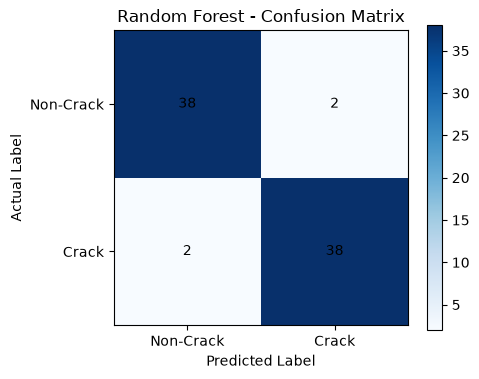

In [44]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))

plt.imshow(cm_rf, cmap="Blues")

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Non-Crack", "Crack"])
plt.yticks([0, 1], ["Non-Crack", "Crack"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

####  Observations

- Random Forest achieved an accuracy of **95.00%** on the test set.
- Precision, recall, and F1-score were all **95.00%**.
- From the confusion matrix, **76 out of 80 test images were classified correctly**.
- The model incorrectly classified **2 non-crack images as crack** and **2 crack images as non-crack**.
- Compared with Logistic Regression, Random Forest produced fewer classification errors on the test set.
- The Random Forest training time (**0.5142 seconds**) and prediction time (**0.0263 seconds**) were higher than those of Logistic Regression.
- This difference is expected because Random Forest uses an ensemble of multiple decision trees, while Logistic Regression uses a single linear model.
- The results show that the handcrafted image features can be used effectively by both linear and nonlinear traditional machine-learning classifiers.

####  Comparison of Traditional ML Models

In [45]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1-Score": [lr_f1, rf_f1],
    "Training Time (s)": [logistic_train_time, rf_train_time],
    "Prediction Time (s)": [
        logistic_prediction_time,
        rf_prediction_time
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9375,0.926829,0.95,0.938272,0.028719,0.000923
1,Random Forest,0.9500,0.950000,0.95,0.950000,0.514166,0.063518


Logistic Regression
→ 93.75% accuracy
→ much lower computation time

Random Forest
→ 95.00% accuracy
→ higher computation time

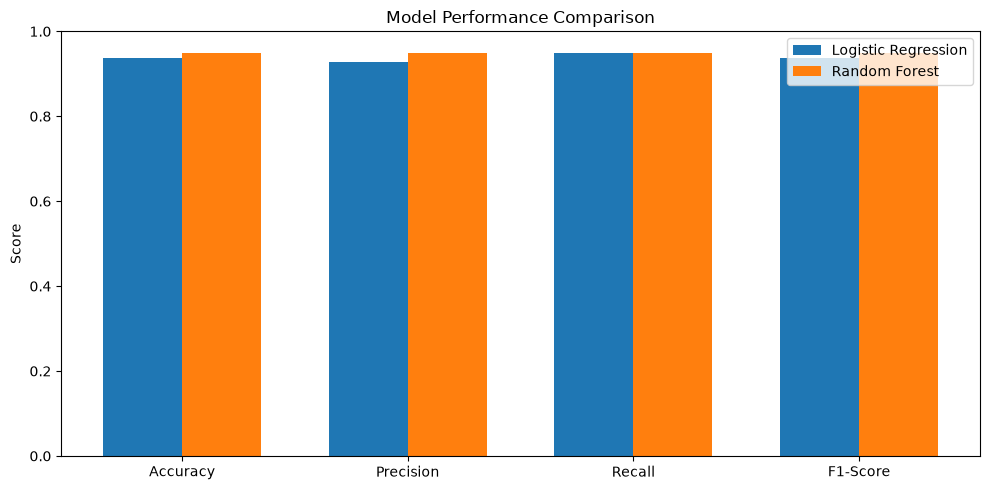

In [46]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    results.loc[0, metrics],
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width / 2,
    results.loc[1, metrics],
    width,
    label="Random Forest"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.legend()

plt.tight_layout()
plt.show()

- Logistic Regression achieved 93.75% accuracy, while Random Forest achieved 95.00%.
- Random Forest achieved slightly higher precision and F1-score than Logistic Regression.
- Logistic Regression required less training time (0.0287 s) than Random Forest (0.5142 s).
- Logistic Regression also required less prediction time (0.0009 s) than Random Forest (0.0635 s).
- Therefore, the two models demonstrate a trade-off between predictive performance and computational time on the same handcrafted feature representation.

Prediction time is measured for the entire 80-image test set, not per image.

## Part C — Representation Improvement of Part A

The baseline image representation uses Canny edge detection with thresholds of 100 and 200.

The Canny edge visualization showed a relatively large number of detected edges. To investigate whether a more selective edge representation can reduce potentially weak edge detections while maintaining or improving classification performance, the Canny thresholds are increased to 150 and 250.

The same image preprocessing, features, train-test split, and classifiers are retained so that the effect of the representation change can be compared fairly.

#### Improved Canny Representation

In [47]:
# Improved Canny thresholds
IMPROVED_CANNY_LOW = 150
IMPROVED_CANNY_HIGH = 250

#### Improved Feature Extraction Function

In [48]:
def extract_improved_features(image_path, img_size=(128, 128)):
    """
    Load an image, preprocess it, and extract features
    using the improved Canny thresholds.
    """

    # Load image
    image = cv2.imread(image_path)

    if image is None:
        return None

    # Preprocessing
    resized = cv2.resize(image, img_size)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Intensity features
    mean_brightness = np.mean(gray)
    median_intensity = np.median(gray)
    contrast = np.std(gray)
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)

    # Pixel ratio features
    dark_pixel_ratio = np.mean(gray < DARK_THRESHOLD)
    bright_pixel_ratio = np.mean(gray > BRIGHT_THRESHOLD)

    # Improved Canny edge detection
    edges = cv2.Canny(
        gray,
        IMPROVED_CANNY_LOW,
        IMPROVED_CANNY_HIGH
    )

    # Edge features
    edge_count = np.sum(edges > 0)
    edge_density = np.mean(edges > 0)

    return {
        "mean_brightness": mean_brightness,
        "median_intensity": median_intensity,
        "contrast": contrast,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "edge_count": edge_count,
        "edge_density": edge_density
    }

#### Improved Feature Dataset

In [49]:
improved_feature_rows = []

# Crack images
for filename in crack_files:
    image_path = os.path.join(CRACK_DIR, filename)

    features = extract_improved_features(image_path)

    if features is not None:
        features["filename"] = filename
        features["label"] = 1
        improved_feature_rows.append(features)


# Non-crack images
for filename in non_crack_files:
    image_path = os.path.join(NON_CRACK_DIR, filename)

    features = extract_improved_features(image_path)

    if features is not None:
        features["filename"] = filename
        features["label"] = 0
        improved_feature_rows.append(features)


improved_features_df = pd.DataFrame(improved_feature_rows)

print("Improved feature dataset shape:", improved_features_df.shape)

Improved feature dataset shape: (400, 11)


#### Compare Baseline and Improved Edge Features

In [50]:
edge_comparison = pd.DataFrame({
    "Representation": [
        "Baseline (100, 200)",
        "Improved (150, 250)"
    ],
    "Mean Edge Count": [
        features_df["edge_count"].mean(),
        improved_features_df["edge_count"].mean()
    ],
    "Mean Edge Density": [
        features_df["edge_density"].mean(),
        improved_features_df["edge_density"].mean()
    ]
})

edge_comparison

,Representation,Mean Edge Count,Mean Edge Density
0,"Baseline (100, 200)",4449.130,0.271553
1,"Improved (150, 250)",3127.745,0.190902


Increasing the Canny thresholds from (100, 200) to (150, 250) reduced the average number of detected edge pixels.

- Mean edge count decreased from **4449.13** to **3127.75**.
- Mean edge density decreased from **0.2716** to **0.1909**.
- This indicates that the improved representation is more selective and detects fewer weak intensity transitions.
- The effect on classification performance still needs to be evaluated using the machine-learning models.

##### Visualization

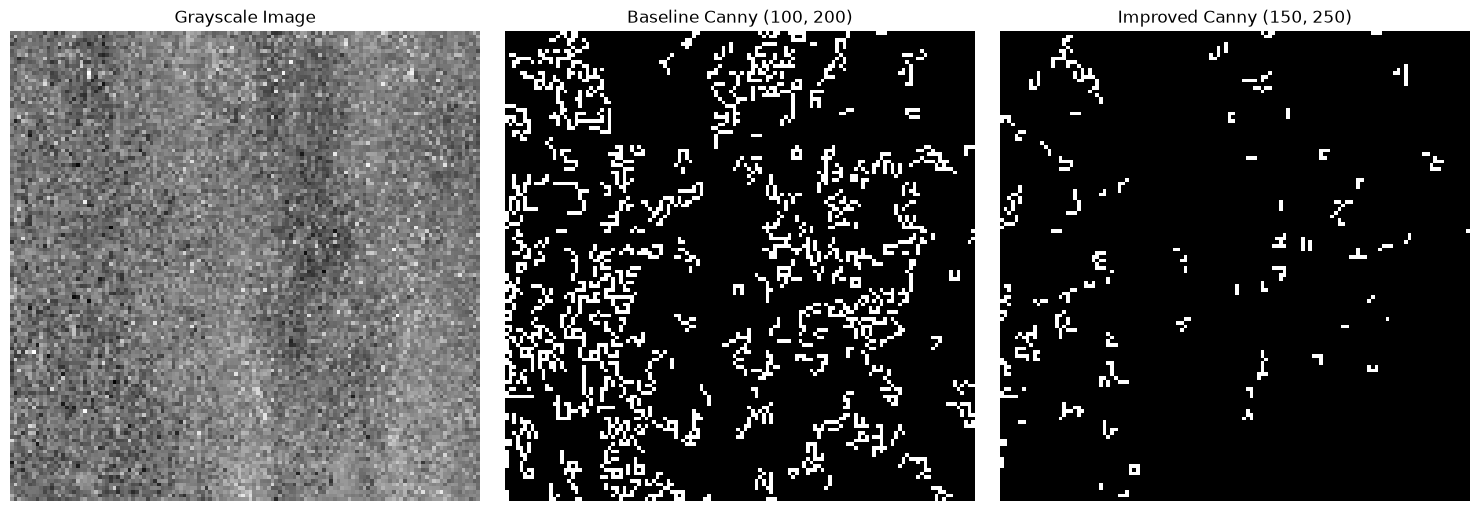

In [51]:
# Use the same grayscale sample image
baseline_edges = cv2.Canny(
    gray,
    CANNY_LOW,
    CANNY_HIGH
)

improved_edges = cv2.Canny(
    gray,
    IMPROVED_CANNY_LOW,
    IMPROVED_CANNY_HIGH
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale Image")
axes[0].axis("off")

axes[1].imshow(baseline_edges, cmap="gray")
axes[1].set_title("Baseline Canny (100, 200)")
axes[1].axis("off")

axes[2].imshow(improved_edges, cmap="gray")
axes[2].set_title("Improved Canny (150, 250)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

#### Improved Train/Test Data

In [52]:
X_improved = improved_features_df[feature_columns]
y_improved = improved_features_df["label"]

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.20,
    random_state=42,
    stratify=y_improved
)

print("Training samples:", X_train_imp.shape[0])
print("Testing samples :", X_test_imp.shape[0])

Training samples: 320
Testing samples : 80


In [53]:
scaler_imp = StandardScaler()

X_train_imp_scaled = scaler_imp.fit_transform(X_train_imp)
X_test_imp_scaled = scaler_imp.transform(X_test_imp)

#### Improved Logistic Regression

In [54]:
improved_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

start_time = time.perf_counter()

improved_lr.fit(X_train_imp_scaled, y_train_imp)

improved_lr_train_time = time.perf_counter() - start_time

start_time = time.perf_counter()

y_pred_imp_lr = improved_lr.predict(X_test_imp_scaled)

improved_lr_prediction_time = time.perf_counter() - start_time

improved_lr_accuracy = accuracy_score(y_test_imp, y_pred_imp_lr)
improved_lr_precision = precision_score(y_test_imp, y_pred_imp_lr)
improved_lr_recall = recall_score(y_test_imp, y_pred_imp_lr)
improved_lr_f1 = f1_score(y_test_imp, y_pred_imp_lr)

print("Improved Logistic Regression")
print("-" * 35)
print(f"Accuracy  : {improved_lr_accuracy:.4f}")
print(f"Precision : {improved_lr_precision:.4f}")
print(f"Recall    : {improved_lr_recall:.4f}")
print(f"F1-score  : {improved_lr_f1:.4f}")
print(f"Train time: {improved_lr_train_time:.6f} sec")
print(f"Pred time : {improved_lr_prediction_time:.6f} sec")

Improved Logistic Regression
-----------------------------------
Accuracy  : 0.9500
Precision : 0.9286
Recall    : 0.9750
F1-score  : 0.9512
Train time: 0.085839 sec
Pred time : 0.003787 sec


#### Improved Random Forest

In [55]:
improved_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

start_time = time.perf_counter()

improved_rf.fit(X_train_imp, y_train_imp)

improved_rf_train_time = time.perf_counter() - start_time

start_time = time.perf_counter()

y_pred_imp_rf = improved_rf.predict(X_test_imp)

improved_rf_prediction_time = time.perf_counter() - start_time

improved_rf_accuracy = accuracy_score(y_test_imp, y_pred_imp_rf)
improved_rf_precision = precision_score(y_test_imp, y_pred_imp_rf)
improved_rf_recall = recall_score(y_test_imp, y_pred_imp_rf)
improved_rf_f1 = f1_score(y_test_imp, y_pred_imp_rf)

print("Improved Random Forest")
print("-" * 35)
print(f"Accuracy  : {improved_rf_accuracy:.4f}")
print(f"Precision : {improved_rf_precision:.4f}")
print(f"Recall    : {improved_rf_recall:.4f}")
print(f"F1-score  : {improved_rf_f1:.4f}")
print(f"Train time: {improved_rf_train_time:.6f} sec")
print(f"Pred time : {improved_rf_prediction_time:.6f} sec")

Improved Random Forest
-----------------------------------
Accuracy  : 0.9500
Precision : 0.9500
Recall    : 0.9500
F1-score  : 0.9500
Train time: 0.301315 sec
Pred time : 0.047147 sec


#### Baseline vs Improved Representation

In [56]:
comparison_results = pd.DataFrame({
    "Representation": [
        "Baseline",
        "Baseline",
        "Improved",
        "Improved"
    ],
    "Canny Thresholds": [
        "(100, 200)",
        "(100, 200)",
        "(150, 250)",
        "(150, 250)"
    ],
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        improved_lr_accuracy,
        improved_rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        improved_lr_precision,
        improved_rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        improved_lr_recall,
        improved_rf_recall
    ],
    "F1-Score": [
        lr_f1,
        rf_f1,
        improved_lr_f1,
        improved_rf_f1
    ],
    "Training Time (s)": [
        logistic_train_time,
        rf_train_time,
        improved_lr_train_time,
        improved_rf_train_time
    ],
    "Prediction Time (s)": [
        logistic_prediction_time,
        rf_prediction_time,
        improved_lr_prediction_time,
        improved_rf_prediction_time
    ]
})

comparison_results

,Representation,Canny Thresholds,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Baseline,"(100, 200)",Logistic Regression,0.9375,0.926829,0.950,0.938272,0.028719,0.000923
1,Baseline,"(100, 200)",Random Forest,0.9500,0.950000,0.950,0.950000,0.514166,0.063518
2,Improved,"(150, 250)",Logistic Regression,0.9500,0.928571,0.975,0.951220,0.085839,0.003787
3,Improved,"(150, 250)",Random Forest,0.9500,0.950000,0.950,0.950000,0.301315,0.047147




- **Accuracy:** Improved Logistic Regression increased from **93.75% → 95.00%**. Random Forest remained at **95.00%**.
- **Training Time:** Improved Logistic Regression took **more time** (0.0858 s vs 0.0287 s), while Improved Random Forest took **less time** (0.3031 s vs 0.5142 s).
- **Prediction Time:** Improved Logistic Regression took **more time** (0.0038 s vs 0.0009 s), while Improved Random Forest took **less time** (0.0471 s vs 0.0635 s).

#### Observations — Representation Improvement

- Increasing the Canny thresholds from (100, 200) to (150, 250) reduced the mean edge count from **4449.13 to 3127.75** and the mean edge density from **0.2716 to 0.1909**.
- With the improved representation, Logistic Regression accuracy increased from **93.75% to 95.00%**, while its F1-score increased from **93.83% to 95.12%**.
- Random Forest achieved **95.00% accuracy and 95.00% F1-score** with both the baseline and improved representations.
- The improved Logistic Regression representation required more training and prediction time than the baseline Logistic Regression.
- The improved Random Forest had lower measured training and prediction times in this run, although timing can vary between executions due to system conditions.
- Therefore, the threshold change produced a more selective Canny edge representation and improved the Logistic Regression test performance, while Random Forest maintained the same test accuracy and F1-score.
- The experiment demonstrates the trade-off between changing the image representation, predictive performance, and computational cost.

# Part B — Text Vectorization and Spam Classification

#### Dataset Loading and Inspection

In [58]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balaka18/email-spam-classification-dataset-csv")

print("Path to dataset files:", path)

100%|██████████| 1.66M/1.66M [00:01<00:00, 883kB/s]

Extracting files...


Path to dataset files: C:\Users\HP\.cache\kagglehub\datasets\balaka18\email-spam-classification-dataset-csv\versions\1


In [59]:
import os

path = r"C:\Users\HP\.cache\kagglehub\datasets\balaka18\email-spam-classification-dataset-csv\versions\1"

print(os.listdir(path))

['emails.csv']


In [61]:
import pandas as pd

df = pd.read_csv( "emails.csv")

print("Shape:", df.shape)
df.head()

Shape: (5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [62]:
print("Number of columns:", len(df.columns))

print("\nFirst 10 columns:")
print(df.columns[:10].tolist())

print("\nLast 5 columns:")
print(df.columns[-5:].tolist())

Number of columns: 3002

First 10 columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou']

Last 5 columns:
['military', 'allowing', 'ff', 'dry', 'Prediction']


In [64]:
print("Data types:")
print(df.dtypes.value_counts())

print("\nTotal missing values:", df.isnull().sum().sum())

print("Duplicate rows:", df.duplicated().sum())

Data types:
int64    3001
str         1
Name: count, dtype: int64

Total missing values: 0
Duplicate rows: 0


#### Spam vs Non-Spam Distribution

In [65]:
class_counts = df["Prediction"].value_counts().sort_index()

print("Email counts:")
print(class_counts)

print("\nEmail percentages:")
print((class_counts / len(df) * 100).round(2))

Email counts:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Email percentages:
Prediction
0    71.0
1    29.0
Name: count, dtype: float64


##### Visualization

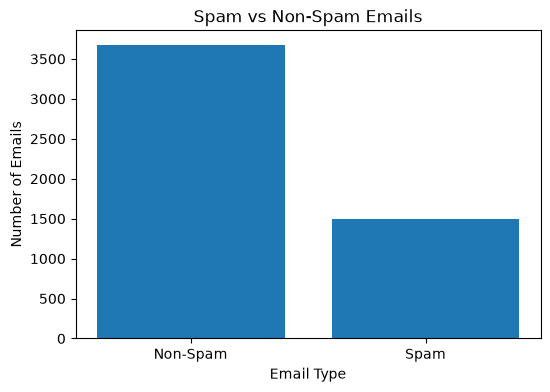

In [66]:
import matplotlib.pyplot as plt

class_counts = df["Prediction"].value_counts().sort_index()

labels = ["Non-Spam", "Spam"]

plt.figure(figsize=(6, 4))
plt.bar(labels, class_counts.values)

plt.title("Spam vs Non-Spam Emails")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")

plt.show()

Total emails: 5,172

Features: 3,000 word-frequency features

Non-spam: 3,672 → 71%

Spam: 1,500 → 29%

Missing values: 0

Duplicate rows: 0

Data types: 3,001 numeric columns + 1 text identifier (Email No.)

#### Feature and Target Separation

The `Email No.` column is only an identifier and does not contain useful information for predicting spam.

Therefore:
- `X` contains the 3,000 word-frequency features.
- `y` contains the spam/non-spam labels.

In [67]:
# Separate features and target
X = df.drop(columns=["Email No.", "Prediction"])
y = df["Prediction"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (5172, 3000)
Target shape: (5172,)

Target distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64


#### Train-Test Split

The dataset is divided into:
- 80% training data
- 20% testing data

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (4137, 3000)
Testing set: (1035, 3000)

Training class distribution:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing class distribution:
Prediction
0    735
1    300
Name: count, dtype: int64


#### Logistic Regression - Baseline model

Logistic Regression is used as the first baseline classifier for spam classification.

The model receives the 3,000 word-frequency features and predicts whether each email is spam or non-spam.

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import time

# Create model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Training time
start_time = time.time()

logistic_model.fit(X_train, y_train)

train_time = time.time() - start_time

# Prediction time
start_time = time.time()

y_pred_lr = logistic_model.predict(X_test)

prediction_time = time.time() - start_time

# Metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression")
print("-" * 40)
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1-score        : {f1:.4f}")
print(f"Training time   : {train_time:.6f} seconds")
print(f"Prediction time : {prediction_time:.6f} seconds")

Logistic Regression
----------------------------------------
Accuracy        : 0.9826
Precision       : 0.9578
Recall          : 0.9833
F1-score        : 0.9704
Training time   : 9.759647 seconds
Prediction time : 0.146717 seconds


##### Confusion Matrix

Confusion Matrix:
[[722  13]
 [  5 295]]


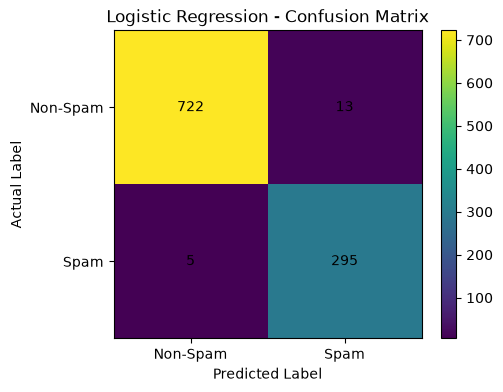

In [73]:
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)


plt.figure(figsize=(5, 4))

plt.imshow(cm_lr)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Non-Spam", "Spam"])
plt.yticks([0, 1], ["Non-Spam", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_lr[i, j],
                 ha="center", va="center")

plt.colorbar()
plt.show()

#### Observation

- Logistic Regression achieved 98.26% accuracy with an F1-score of 97.04%.
- It correctly classified 1,017 out of 1,035 test emails.
- Only 5 spam emails were incorrectly classified as non-spam, while 13 non-spam emails were classified as spam.
- The high recall of 98.33% shows that the model detected most spam emails.
- Training took about 9.76 seconds, while prediction took only 0.15 seconds.

### Naive Bayes

Multinomial Naive Bayes is suitable for word-frequency data because it uses the frequency of features to estimate the probability that an email belongs to each class.


In [71]:
from sklearn.naive_bayes import MultinomialNB

# Create model
nb_model = MultinomialNB()

# Training time
start_time = time.time()

nb_model.fit(X_train, y_train)

nb_train_time = time.time() - start_time

# Prediction time
start_time = time.time()

y_pred_nb = nb_model.predict(X_test)

nb_prediction_time = time.time() - start_time

# Metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print("Multinomial Naive Bayes")
print("-" * 40)
print(f"Accuracy        : {nb_accuracy:.4f}")
print(f"Precision       : {nb_precision:.4f}")
print(f"Recall          : {nb_recall:.4f}")
print(f"F1-score        : {nb_f1:.4f}")
print(f"Training time   : {nb_train_time:.6f} seconds")
print(f"Prediction time : {nb_prediction_time:.6f} seconds")

Multinomial Naive Bayes
----------------------------------------
Accuracy        : 0.9420
Precision       : 0.8681
Recall          : 0.9433
F1-score        : 0.9042
Training time   : 0.341606 seconds
Prediction time : 0.099560 seconds


Confusion Matrix:
[[692  43]
 [ 17 283]]


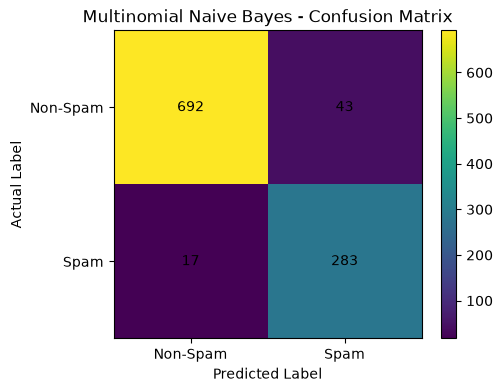

In [76]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Confusion Matrix:")
print(cm_nb)

plt.figure(figsize=(5, 4))

plt.imshow(cm_nb)

plt.title("Multinomial Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Non-Spam", "Spam"])
plt.yticks([0, 1], ["Non-Spam", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_nb[i, j],
                 ha="center", va="center")

plt.colorbar()
plt.show()


#### Observation

- Multinomial Naive Bayes achieved 94.20% accuracy and a 90.42% F1-score.
- It correctly classified 975 out of 1,035 test emails.
- 17 spam emails were incorrectly classified as non-spam, while 43 non-spam emails were classified as spam.
- The model trained much faster than Logistic Regression, taking only 0.34 seconds.
- However, its precision and F1-score were lower than Logistic Regression.

#### Random Forest

Random Forest is used as a tree-based classifier.

It combines multiple decision trees and can capture non-linear relationships between the word-frequency features and the spam/non-spam classes.

In [77]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Training time
start_time = time.time()

rf_model.fit(X_train, y_train)

rf_train_time = time.time() - start_time

# Prediction time
start_time = time.time()

y_pred_rf = rf_model.predict(X_test)

rf_prediction_time = time.time() - start_time

# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest")
print("-" * 40)
print(f"Accuracy        : {rf_accuracy:.4f}")
print(f"Precision       : {rf_precision:.4f}")
print(f"Recall          : {rf_recall:.4f}")
print(f"F1-score        : {rf_f1:.4f}")
print(f"Training time   : {rf_train_time:.6f} seconds")
print(f"Prediction time : {rf_prediction_time:.6f} seconds")

Random Forest
----------------------------------------
Accuracy        : 0.9643
Precision       : 0.9340
Recall          : 0.9433
F1-score        : 0.9386
Training time   : 1.611192 seconds
Prediction time : 0.264550 seconds


Confusion Matrix:
[[715  20]
 [ 17 283]]


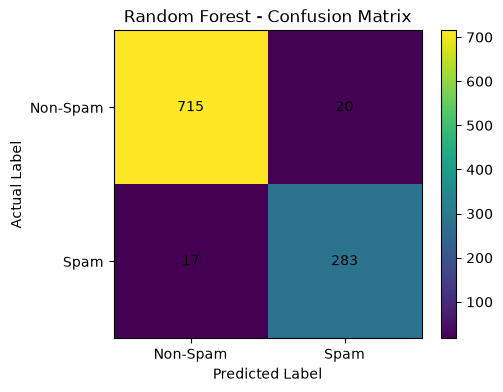

In [78]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

plt.figure(figsize=(5, 4))

plt.imshow(cm_rf)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Non-Spam", "Spam"])
plt.yticks([0, 1], ["Non-Spam", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_rf[i, j],
                 ha="center", va="center")

plt.colorbar()
plt.show()

#### Observation

- Random Forest achieved 96.43% accuracy and a 93.86% F1-score.
- It correctly classified 998 out of 1,035 test emails.
- 17 spam emails were incorrectly classified as non-spam, while 20 non-spam emails were classified as spam.
- Its performance was higher than Multinomial Naive Bayes but lower than Logistic Regression.
- Training took 1.61 seconds and prediction took 0.26 seconds.

#### Compare All Three Models

In [79]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        nb_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        nb_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        nb_recall,
        rf_recall
    ],
    "F1-score": [
        f1,
        nb_f1,
        rf_f1
    ],
    "Training Time (s)": [
        train_time,
        nb_train_time,
        rf_train_time
    ],
    "Prediction Time (s)": [
        prediction_time,
        nb_prediction_time,
        rf_prediction_time
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.982609,0.957792,0.983333,0.970395,9.759647,0.146717
1,Multinomial Naive Bayes,0.942029,0.868098,0.943333,0.904153,0.341606,0.099560
2,Random Forest,0.964251,0.933993,0.943333,0.938640,1.611192,0.264550


#### Comparasion
- Logistic Regression achieved the highest performance across the main evaluation metrics, with 98.26% accuracy and a 97.04% F1-score.
- Random Forest achieved 96.43% accuracy, performing better than Multinomial Naive Bayes.
- Multinomial Naive Bayes had the lowest training and prediction times among the three models.
- Logistic Regression required the most training time but provided the strongest classification performance.
- The results show a trade-off between computational time and classification performance across the three models.

## Part C — Improving Feature Representation of Part B

The original dataset contains 3,000 word-frequency features.

To improve the representation, Chi-square feature selection is used to retainthe 1,000 features that have the strongest relationship with the target class.

This reduces the dimensionality from 3,000 to 1,000 features while retaining the most informative features for classification.

Feature selection is performed only on the training data to avoid data leakage.

##### CHi Squared Feature Selection

In [ ]:
#CHi Squared Feature Selection
from sklearn.feature_selection import SelectKBest, chi2

# Select the 1,000 most informative features
selector = SelectKBest(score_func=chi2, k=1000)

# Fit only on training data
X_train_selected = selector.fit_transform(X_train, y_train)

# Apply the same selection to test data
X_test_selected = selector.transform(X_test)

print("Original feature count:", X_train.shape[1])
print("Reduced feature count:", X_train_selected.shape[1])

print("\nTraining shape:", X_train_selected.shape)
print("Testing shape:", X_test_selected.shape)

Original feature count: 3000
Reduced feature count: 1000

Training shape: (4137, 1000)
Testing shape: (1035, 1000)


#### Train Logistic Regression on Reduced Features

In [81]:
# Create Logistic Regression model
logistic_selected = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Training time
start_time = time.time()

logistic_selected.fit(X_train_selected, y_train)

selected_train_time = time.time() - start_time

# Prediction time
start_time = time.time()

y_pred_selected = logistic_selected.predict(X_test_selected)

selected_prediction_time = time.time() - start_time

# Metrics
selected_accuracy = accuracy_score(y_test, y_pred_selected)
selected_precision = precision_score(y_test, y_pred_selected)
selected_recall = recall_score(y_test, y_pred_selected)
selected_f1 = f1_score(y_test, y_pred_selected)

print("Logistic Regression - Selected Features")
print("-" * 45)
print(f"Accuracy        : {selected_accuracy:.4f}")
print(f"Precision       : {selected_precision:.4f}")
print(f"Recall          : {selected_recall:.4f}")
print(f"F1-score        : {selected_f1:.4f}")
print(f"Training time   : {selected_train_time:.6f} seconds")
print(f"Prediction time : {selected_prediction_time:.6f} seconds")

Logistic Regression - Selected Features
---------------------------------------------
Accuracy        : 0.9729
Precision       : 0.9474
Recall          : 0.9600
F1-score        : 0.9536
Training time   : 4.488728 seconds
Prediction time : 0.009971 seconds


##### Confusion Matrix

Confusion Matrix:
[[719  16]
 [ 12 288]]


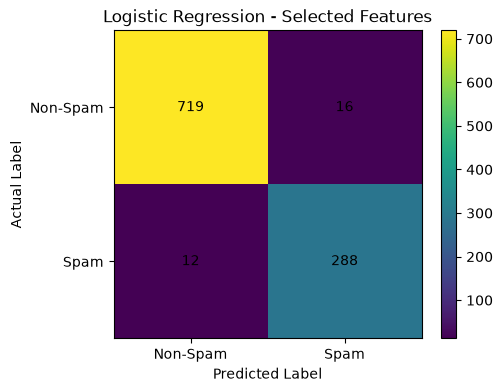

In [82]:
cm_selected = confusion_matrix(y_test, y_pred_selected)

print("Confusion Matrix:")
print(cm_selected)

plt.figure(figsize=(5, 4))

plt.imshow(cm_selected)

plt.title("Logistic Regression - Selected Features")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Non-Spam", "Spam"])
plt.yticks([0, 1], ["Non-Spam", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(
            j, i,
            cm_selected[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

#### Comparing Original vs Improved model

In [83]:
part_c_results = pd.DataFrame({
    "Representation": [
        "Original",
        "Chi-square Selected"
    ],
    "Features": [
        X_train.shape[1],
        X_train_selected.shape[1]
    ],
    "Accuracy": [
        accuracy,
        selected_accuracy
    ],
    "Precision": [
        precision,
        selected_precision
    ],
    "Recall": [
        recall,
        selected_recall
    ],
    "F1-score": [
        f1,
        selected_f1
    ],
    "Training Time (s)": [
        train_time,
        selected_train_time
    ],
    "Prediction Time (s)": [
        prediction_time,
        selected_prediction_time
    ]
})

part_c_results

,Representation,Features,Accuracy,Precision,Recall,F1-score,Training Time (s),Prediction Time (s)
0,Original,3000,0.982609,0.957792,0.983333,0.970395,9.759647,0.146717
1,Chi-square Selected,1000,0.972947,0.947368,0.960000,0.953642,4.488728,0.009971


##### Observation

- Chi-square feature selection reduced the number of features from 3,000 to 1,000, reducing the dimensionality by 66.7%.
- Accuracy decreased slightly from 98.26% to 97.29%, while F1-score decreased from 97.04% to 95.36%.
- Training time decreased from 9.76 seconds to 4.49 seconds.
- Prediction time decreased from 0.147 seconds to 0.010 seconds.
- The reduced representation therefore provides a trade-off between a small decrease in classification performance and a substantial reduction in computational cost.

The provided Kaggle dataset does not contain the original email bodies. Instead, each email is already represented using 3,000 word-frequency features.

Therefore, CountVectorizer and TF-IDF Vectorizer were not applied again. The existing numerical word-frequency representation was used directly for classification.

### Conclusion

####  Part A — Asphalt Crack Classification

| | Final Result |
|---|---|
| 🏆 Best final model | **Logistic Regression** |
| Accuracy | **95.00%** |
| F1-score | **95.12%** |
| Recall | **97.50%** |

**Final Result → Improved Logistic Regression**

####  Part C — Improved Canny Representation

**Baseline → Improved Canny**

| | Baseline | Improved Canny |
|---|---:|---:|
| Canny Thresholds | 100, 200 | **150, 250** |
| Accuracy — Logistic Regression | 93.75% | **95.00%** |
| F1-score — Logistic Regression | 93.83% | **95.12%** |
| Recall — Logistic Regression | 95.00% | **97.50%** |
| Edge Density | 0.272 | **0.191** |

The improved Canny representation used higher thresholds, making the edge
detector more selective and reducing unnecessary edges.

This improved Logistic Regression accuracy from **93.75% → 95.00%** and
F1-score from **93.83% → 95.12%**.

Random Forest remained at **95.00% accuracy** after the representation
improvement.

 Final model: **Improved Logistic Regression — 95.00% accuracy, 95.12% F1-score**

**Takeaway:** A more selective edge representation improved Logistic
Regression while reducing the amount of detected edge information.

---

####  Part B — Email Spam Classification

| | Final Result |
|---|---|
| 🏆 Best final model | **Logistic Regression** |
| Features | **3,000** |
| Accuracy | **98.26%** |
| F1-score | **97.04%** |
| Recall | **98.33%** |

Logistic Regression achieved the strongest classification performance among
the three models.

**Final Result → Logistic Regression with Original Features**

####  Part C — Chi-square Feature Selection

**3,000 features → 1,000 features**

| | Original | Chi-square Selected |
|---|---:|---:|
| Features | 3,000 | **1,000** |
| Accuracy | **98.26%** | 97.29% |
| F1-score | **97.04%** | 95.36% |
| Training time | 9.76 s | **4.49 s** |
| Prediction time | 0.147 s | **0.010 s** |

Feature selection reduced the dimensionality by **66.7%** and substantially
reduced training and prediction time, but resulted in a small decrease in
classification performance.

 Final model: **Original Logistic Regression — 98.26% accuracy, 97.04% F1-score**

 Efficient alternative: **Chi-square selected representation — 1,000 features**

**Takeaway:** The original representation provided better predictive
performance, while feature selection provided a much more compact and
computationally efficient representation.

---

###  Final Takeaway

| Task | Final Representation | Final Model | Accuracy |
|---|---|---|---:|
|  Asphalt Crack | **Improved Canny** | **Logistic Regression** | **95.00%** |
|  Email Spam | **Original 3,000 features** | **Logistic Regression** | **98.26%** |

**Overall:** Logistic Regression gave the strongest observed classification
performance for both tasks. The Part C experiments demonstrated two different
effects of representation improvement: the improved Canny representation
increased crack-classification performance, while Chi-square feature selection
reduced email-classification computation at the cost of some predictive
performance.